# 08. UTCI and heat stress

Everything so far has been physics about a place. This notebook turns it into a number about a
person: how hot does it *feel* to stand here, and how fast is that hurting you.

UTCI is the answer, in °C. On this day the open road comes out at 48 °C and the shaded footpath
next to it at 42 °C — and 42 is not comfortable, it is just six degrees less bad. That gap,
counted up minute by minute along a walk, is what the app is choosing between.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CONFIG = json.load(open("config.json"))

W, H = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
CELL = CONFIG["cell_size"]
DATE = CONFIG["date"]

half = int(3000 / CELL / 2)
CROP = np.s_[H // 2 - half:H // 2 + half, W // 2 - half:W // 2 + half]
HOURS = list(range(6, 21))

mrt  = {h: np.load(f"out/rasters/mrt_{h:02d}.npy")[CROP] for h in HOURS}     # 07
dsm  = np.load("out/rasters/dsm_buildings.npy")[CROP]
ground = dsm <= 0

w = pd.DataFrame(json.load(open(f"data/weather_{DATE}.json"))["hourly"])
w.index = pd.to_datetime(w.pop("time")).dt.hour
w["wind_ms"] = w["wind_speed_10m"] / 3.6

print(f"crop {2 * half} x {2 * half} cells   {DATE}")

crop 1500 x 1500 cells   2026-01-27


## What UTCI is

A body does not read a thermometer. It sweats, shivers, moves blood to the skin, and how bad
things feel depends on all four of air temperature, radiation, wind and humidity at once — 42 °C
dry with a breeze is survivable, 42 °C humid and still is not.

UTCI takes those four and answers one question: **what plain air temperature, on a calm humid
day with no sun, would put your body under the same strain?** So a UTCI of 48 °C means what you
are standing in is as hard on you as a still, shaded 48 °C.

| input | where it comes from |
|---|---|
| air temperature | 04 |
| mean radiant temperature | 07 — the one that varies across the street |
| wind at 10 m | 04 |
| humidity | 04 |

Three of the four are the same everywhere in the city today. MRT is the one with a map.

## The polynomial

Behind UTCI is a full physiological simulation — a body model with skin layers, blood flow and
sweat, run forward until it settles. Far too slow for six million cells.

So Bröde et al. ran it thousands of times and fitted the output with a polynomial: 210 terms,
6th order, in air temperature, wind, MRT-minus-air and vapour pressure. That polynomial *is* the
published UTCI, and there is nothing to derive here — it gets transcribed.

The table below is a straight copy of the one in the `shademe` package, where each row is
`(coefficient, exponents of ta, va, mrt-ta, pa)`. It was machine-parsed from two independent
implementations — `pythermalcomfort` and ECMWF's `thermofeel`, the code behind ERA5-HEAT — which
agreed on all 210 terms.

In [2]:
UTCI_COEF = (
    (            1.0,1,0,0,0), (    0.607562052,0,0,0,0), (  -0.0227712343,1,0,0,0),
    ( 8.06470249e-04,2,0,0,0), (-1.54271372e-04,3,0,0,0), (-3.24651735e-06,4,0,0,0),
    ( 7.32602852e-08,5,0,0,0), ( 1.35959073e-09,6,0,0,0), (    -2.25836520,0,1,0,0),
    (   0.0880326035,1,1,0,0), (  0.00216844454,2,1,0,0), (-1.53347087e-05,3,1,0,0),
    (-5.72983704e-07,4,1,0,0), (-2.55090145e-09,5,1,0,0), (   -0.751269505,0,2,0,0),
    ( -0.00408350271,1,2,0,0), (-5.21670675e-05,2,2,0,0), ( 1.94544667e-06,3,2,0,0),
    ( 1.14099531e-08,4,2,0,0), (    0.158137256,0,3,0,0), (-6.57263143e-05,1,3,0,0),
    ( 2.22697524e-07,2,3,0,0), (-4.16117031e-08,3,3,0,0), (  -0.0127762753,0,4,0,0),
    ( 9.66891875e-06,1,4,0,0), ( 2.52785852e-09,2,4,0,0), ( 4.56306672e-04,0,5,0,0),
    (-1.74202546e-07,1,5,0,0), (-5.91491269e-06,0,6,0,0), (    0.398374029,0,0,1,0),
    ( 1.83945314e-04,1,0,1,0), (-1.73754510e-04,2,0,1,0), (-7.60781159e-07,3,0,1,0),
    ( 3.77830287e-08,4,0,1,0), ( 5.43079673e-10,5,0,1,0), (  -0.0200518269,0,1,1,0),
    ( 8.92859837e-04,1,1,1,0), ( 3.45433048e-06,2,1,1,0), (-3.77925774e-07,3,1,1,0),
    (-1.69699377e-09,4,1,1,0), ( 1.69992415e-04,0,2,1,0), (-4.99204314e-05,1,2,1,0),
    ( 2.47417178e-07,2,2,1,0), ( 1.07596466e-08,3,2,1,0), ( 8.49242932e-05,0,3,1,0),
    ( 1.35191328e-06,1,3,1,0), (-6.21531254e-09,2,3,1,0), (-4.99410301e-06,0,4,1,0),
    (-1.89489258e-08,1,4,1,0), ( 8.15300114e-08,0,5,1,0), ( 7.55043090e-04,0,0,2,0),
    (-5.65095215e-05,1,0,2,0), (-4.52166564e-07,2,0,2,0), ( 2.46688878e-08,3,0,2,0),
    ( 2.42674348e-10,4,0,2,0), ( 1.54547250e-04,0,1,2,0), ( 5.24110970e-06,1,1,2,0),
    (-8.75874982e-08,2,1,2,0), (-1.50743064e-09,3,1,2,0), (-1.56236307e-05,0,2,2,0),
    (-1.33895614e-07,1,2,2,0), ( 2.49709824e-09,2,2,2,0), ( 6.51711721e-07,0,3,2,0),
    ( 1.94960053e-09,1,3,2,0), (-1.00361113e-08,0,4,2,0), (-1.21206673e-05,0,0,3,0),
    (-2.18203660e-07,1,0,3,0), ( 7.51269482e-09,2,0,3,0), ( 9.79063848e-11,3,0,3,0),
    ( 1.25006734e-06,0,1,3,0), (-1.81584736e-09,1,1,3,0), (-3.52197671e-10,2,1,3,0),
    (-3.36514630e-08,0,2,3,0), ( 1.35908359e-10,1,2,3,0), ( 4.17032620e-10,0,3,3,0),
    (-1.30369025e-09,0,0,4,0), ( 4.13908461e-10,1,0,4,0), ( 9.22652254e-12,2,0,4,0),
    (-5.08220384e-09,0,1,4,0), (-2.24730961e-11,1,1,4,0), ( 1.17139133e-10,0,2,4,0),
    ( 6.62154879e-10,0,0,5,0), ( 4.03863260e-13,1,0,5,0), ( 1.95087203e-12,0,1,5,0),
    (-4.73602469e-12,0,0,6,0), (     5.12733497,0,0,0,1), (   -0.312788561,1,0,0,1),
    (  -0.0196701861,2,0,0,1), ( 9.99690870e-04,3,0,0,1), ( 9.51738512e-06,4,0,0,1),
    (-4.66426341e-07,5,0,0,1), (    0.548050612,0,1,0,1), ( -0.00330552823,1,1,0,1),
    ( -0.00164119440,2,1,0,1), (-5.16670694e-06,3,1,0,1), ( 9.52692432e-07,4,1,0,1),
    (  -0.0429223622,0,2,0,1), (  0.00500845667,1,2,0,1), ( 1.00601257e-06,2,2,0,1),
    (-1.81748644e-06,3,2,0,1), (-1.25813502e-03,0,3,0,1), (-1.79330391e-04,1,3,0,1),
    ( 2.34994441e-06,2,3,0,1), ( 1.29735808e-04,0,4,0,1), ( 1.29064870e-06,1,4,0,1),
    (-2.28558686e-06,0,5,0,1), (  -0.0369476348,0,0,1,1), (  0.00162325322,1,0,1,1),
    (-3.14279680e-05,2,0,1,1), ( 2.59835559e-06,3,0,1,1), (-4.77136523e-08,4,0,1,1),
    ( 8.64203390e-03,0,1,1,1), (-6.87405181e-04,1,1,1,1), (-9.13863872e-06,2,1,1,1),
    ( 5.15916806e-07,3,1,1,1), (-3.59217476e-05,0,2,1,1), ( 3.28696511e-05,1,2,1,1),
    (-7.10542454e-07,2,2,1,1), (-1.24382300e-05,0,3,1,1), (-7.38584400e-09,1,3,1,1),
    ( 2.20609296e-07,0,4,1,1), (-7.32469180e-04,0,0,2,1), (-1.87381964e-05,1,0,2,1),
    ( 4.80925239e-06,2,0,2,1), (-8.75492040e-08,3,0,2,1), ( 2.77862930e-05,0,1,2,1),
    (-5.06004592e-06,1,1,2,1), ( 1.14325367e-07,2,1,2,1), ( 2.53016723e-06,0,2,2,1),
    (-1.72857035e-08,1,2,2,1), (-3.95079398e-08,0,3,2,1), (-3.59413173e-07,0,0,3,1),
    ( 7.04388046e-07,1,0,3,1), (-1.89309167e-08,2,0,3,1), (-4.79768731e-07,0,1,3,1),
    ( 7.96079978e-09,1,1,3,1), ( 1.62897058e-09,0,2,3,1), ( 3.94367674e-08,0,0,4,1),
    (-1.18566247e-09,1,0,4,1), ( 3.34678041e-10,0,1,4,1), (-1.15606447e-10,0,0,5,1),
    (    -2.80626406,0,0,0,2), (    0.548712484,1,0,0,2), ( -0.00399428410,2,0,0,2),
    (-9.54009191e-04,3,0,0,2), ( 1.93090978e-05,4,0,0,2), (   -0.308806365,0,1,0,2),
    (   0.0116952364,1,1,0,2), ( 4.95271903e-04,2,1,0,2), (-1.90710882e-05,3,1,0,2),
    (  0.00210787756,0,2,0,2), (-6.98445738e-04,1,2,0,2), ( 2.30109073e-05,2,2,0,2),
    ( 4.17856590e-04,0,3,0,2), (-1.27043871e-05,1,3,0,2), (-3.04620472e-06,0,4,0,2),
    (   0.0514507424,0,0,1,2), ( -0.00432510997,1,0,1,2), ( 8.99281156e-05,2,0,1,2),
    (-7.14663943e-07,3,0,1,2), (-2.66016305e-04,0,1,1,2), ( 2.63789586e-04,1,1,1,2),
    (-7.01199003e-06,2,1,1,2), (-1.06823306e-04,0,2,1,2), ( 3.61341136e-06,1,2,1,2),
    ( 2.29748967e-07,0,3,1,2), ( 3.04788893e-04,0,0,2,2), (-6.42070836e-05,1,0,2,2),
    ( 1.16257971e-06,2,0,2,2), ( 7.68023384e-06,0,1,2,2), (-5.47446896e-07,1,1,2,2),
    (-3.59937910e-08,0,2,2,2), (-4.36497725e-06,0,0,3,2), ( 1.68737969e-07,1,0,3,2),
    ( 2.67489271e-08,0,1,3,2), ( 3.23926897e-09,0,0,4,2), (  -0.0353874123,0,0,0,3),
    (   -0.221201190,1,0,0,3), (   0.0155126038,2,0,0,3), (-2.63917279e-04,3,0,0,3),
    (   0.0453433455,0,1,0,3), ( -0.00432943862,1,1,0,3), ( 1.45389826e-04,2,1,0,3),
    ( 2.17508610e-04,0,2,0,3), (-6.66724702e-05,1,2,0,3), ( 3.33217140e-05,0,3,0,3),
    ( -0.00226921615,0,0,1,3), ( 3.80261982e-04,1,0,1,3), (-5.45314314e-09,2,0,1,3),
    (-7.96355448e-04,0,1,1,3), ( 2.53458034e-05,1,1,1,3), (-6.31223658e-06,0,2,1,3),
    ( 3.02122035e-04,0,0,2,3), (-4.77403547e-06,1,0,2,3), ( 1.73825715e-06,0,1,2,3),
    (-4.09087898e-07,0,0,3,3), (    0.614155345,0,0,0,4), (  -0.0616755931,1,0,0,4),
    (  0.00133374846,2,0,0,4), (  0.00355375387,0,1,0,4), (-5.13027851e-04,1,1,0,4),
    ( 1.02449757e-04,0,2,0,4), ( -0.00148526421,0,0,1,4), (-4.11469183e-05,1,0,1,4),
    (-6.80434415e-06,0,1,1,4), (-9.77675906e-06,0,0,2,4), (   0.0882773108,0,0,0,5),
    ( -0.00301859306,1,0,0,5), (  0.00104452989,0,1,0,5), ( 2.47090539e-04,0,0,1,5),
    (  0.00148348065,0,0,0,6),
)

Evaluating it is one loop. Each row says multiply these four powers together and add. The only
care needed is memory: at six million cells, holding every power of every variable at once is
gigabytes, so it goes through in chunks.

The fit was only ever tested over a certain range, so inputs outside it get clipped onto the
edge rather than extrapolated into nonsense.

In [3]:
UTCI_TA = (-50.0, 50.0)      # air temperature, degC
UTCI_DT = (-30.0, 70.0)      # mrt - ta, K        <- the one that bites in a hot street
UTCI_VA = (0.5, 17.0)        # wind at 10 m, m/s  <- note the 0.5 floor: never perfectly still

C = np.array([r[0] for r in UTCI_COEF])
E = np.array([r[1:] for r in UTCI_COEF])

def utci(ta, tmrt, va, rh):
    """UTCI in degC. Scalars or whole rasters."""
    ta, tmrt, va, rh = np.broadcast_arrays(*(np.asarray(x, float) for x in (ta, tmrt, va, rh)))
    shape = ta.shape
    ta, dmrt = ta.ravel(), (tmrt - ta).ravel()
    va = va.ravel()
    pa = (6.112 * np.exp(17.62 * ta / (243.12 + ta)) * rh.ravel() / 100) / 10   # kPa (Magnus)

    ta   = np.clip(ta,   *UTCI_TA)
    dmrt = np.clip(dmrt, *UTCI_DT)
    va   = np.clip(va,   *UTCI_VA)

    out = np.empty(ta.shape)
    for s in range(0, ta.size, 1 << 19):
        j = np.s_[s:s + (1 << 19)]
        pw = [[None] + [v[j] ** k for k in range(1, 7)] for v in (ta, va, dmrt, pa)]
        acc = np.zeros(ta[j].shape)
        for c, ex in zip(C, E):
            term = c
            for i in np.nonzero(ex)[0]:
                term = term * pw[i][ex[i]]
            acc += term
        out[j] = acc
    return out.reshape(shape)

### The four spots, one last time

Same four cells as 06 and 07, at 14:00. Air is 42.4 °C at all of them; wind is 4.4 m/s at all of
them; the humidity is 14% at all of them. Only MRT differs.

In [4]:
from pyproj import Transformer

to_m = Transformer.from_crs(CONFIG["crs"]["wgs84"], CONFIG["crs"]["mga55"], always_xy=True)
R0, C0 = CROP[0].start, CROP[1].start

def cell_of(lon, lat):
    x, y = to_m.transform(lon, lat)
    return (int((CONFIG["grid"]["maxy"] - y) / CELL) - R0,
            int((x - CONFIG["grid"]["minx"]) / CELL) - C0)

SPOTS = {"open road":   cell_of(144.97043, -37.81696),
         "shaded road": cell_of(144.96670, -37.81319),
         "park lawn":   cell_of(144.97238, -37.82049),
         "laneway":     cell_of(144.96541, -37.81279)}

HOUR = 14
hw = w.loc[HOUR]
ta, rh, va = hw["temperature_2m"], hw["relative_humidity_2m"], hw["wind_ms"]

print(f"{HOUR}:00   air {ta:.1f} C   wind {va:.1f} m/s   RH {rh:.0f}%\n")
print(f"{'':13s} {'MRT':>7s} {'UTCI':>7s}")
for name, (r, c) in SPOTS.items():
    m = mrt[HOUR][r, c]
    u = utci(ta, m, va, rh)
    print(f"{name:13s} {m:6.1f}C {float(u):6.1f}C")

14:00   air 42.4 C   wind 4.4 m/s   RH 14%

                  MRT    UTCI
open road       67.7C   47.6C
shaded road     38.8C   41.6C
park lawn       67.3C   47.6C
laneway         42.0C   42.2C


Look at what happened to the spread. MRT ranged over **29 °C** between those cells; UTCI ranges
over **6 °C**.

That is not the model losing the shade. It is the body being harder to move than a thermometer —
sweat and blood flow absorb a lot of the radiation load before it turns into strain. Shade is
worth six degrees of felt heat, not thirty. Six degrees is still the difference between two
official stress categories, and it still adds up over a twenty minute walk.

## Wind is the other lever

MRT is not the only thing UTCI answers to. Below, the same sweep of MRT twice: once under
mid-morning conditions, once under mid-afternoon, one line per wind speed.

The lines swap order between the two panels, and that is the whole cell. At 33 °C wind is a fan —
it carries heat off you and every extra m/s is worth degrees. At 42 °C the air is hotter than
your skin, so the same wind is a hair dryer, and it makes things slightly **worse**.

Which is worth knowing before promising anyone that a breezy street is a cool one.

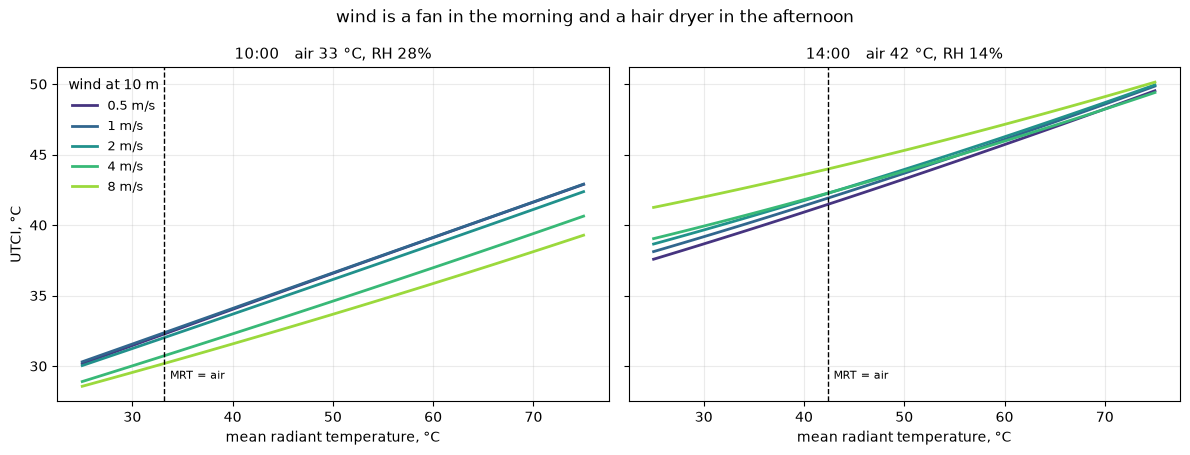

In [5]:
m_axis = np.linspace(25, 75, 120)
SPEEDS = [0.5, 1, 2, 4, 8]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, h in zip(axes, (10, 14)):
    ta_h, rh_h = w.loc[h, "temperature_2m"], w.loc[h, "relative_humidity_2m"]
    for va, colour in zip(SPEEDS, plt.cm.viridis(np.linspace(0.15, 0.85, len(SPEEDS)))):
        ax.plot(m_axis, utci(ta_h, m_axis, va, rh_h), color=colour, lw=2, label=f"{va} m/s")
    ax.axvline(ta_h, color="k", ls="--", lw=1)
    ax.annotate("MRT = air", (ta_h, 0.06), xycoords=("data", "axes fraction"),
                fontsize=8, ha="left", va="bottom", xytext=(4, 0), textcoords="offset points")
    ax.set_xlabel("mean radiant temperature, °C")
    ax.set_title(f"{h}:00   air {ta_h:.0f} °C, RH {rh_h:.0f}%", fontsize=11)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("UTCI, °C")
axes[0].legend(frameon=False, fontsize=9, title="wind at 10 m", loc="upper left")
fig.suptitle("wind is a fan in the morning and a hair dryer in the afternoon", fontsize=12)
fig.tight_layout()

## Stress

UTCI comes with ten official bands. The one in the middle, **9 to 26 °C, is "no thermal stress"**
— inside it a body holds its temperature without working at it. Everything else is a named
degree of trouble.

| UTCI | category |
|---|---|
| above 46 | extreme heat stress |
| 38 – 46 | very strong heat stress |
| 32 – 38 | strong heat stress |
| 26 – 32 | moderate heat stress |
| 9 – 26 | **no thermal stress** |
| 0 – 9 | slight cold stress |
| below 0 | four more, down to extreme cold |

For routing we need a number, not a label, so: **stress is how many degrees you are outside the
band.** Zero inside it, rising either side, no jumps at the edges.

In [6]:
NO_STRESS = (9.0, 26.0)

BANDS = [-40, -27, -13, 0, 9, 26, 32, 38, 46]
LABELS = ["extreme cold", "very strong cold", "strong cold", "moderate cold", "slight cold",
          "no stress", "moderate heat", "strong heat", "very strong heat", "extreme heat"]
# Bands are the published ones. The colours are ours -- the heat end is spread wide on purpose,
# because on a day like this the whole city lands in the top two and they have to tell apart.
COLOURS = ["#08306b", "#2171b5", "#6baed6", "#c6dbef", "#deebf7",
           "#7fbf7b", "#ffeda0", "#fec44f", "#fd8d3c", "#99000d"]

def stress(u):
    """Degrees outside the no-stress band. 0 inside, positive both sides."""
    return np.maximum(NO_STRESS[0] - u, 0) + np.maximum(u - NO_STRESS[1], 0)

def band(u):
    return np.searchsorted(BANDS, u, side="right")

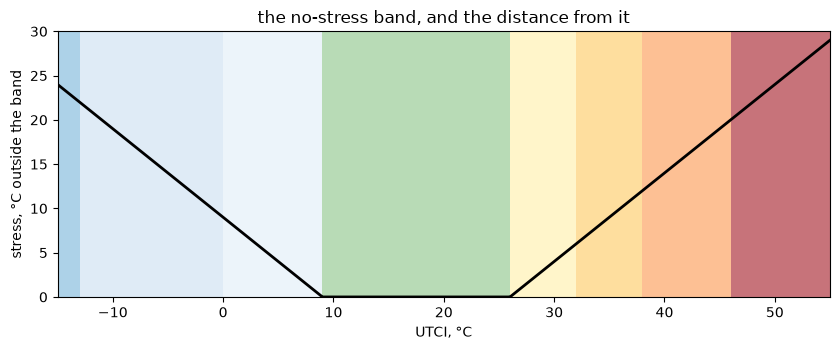

In [7]:
u_axis = np.linspace(-15, 55, 400)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, colour in enumerate(COLOURS):
    lo = BANDS[i - 1] if i else -15
    hi = BANDS[i] if i < len(BANDS) else 55
    ax.axvspan(lo, hi, color=colour, alpha=0.55, lw=0)

ax.plot(u_axis, stress(u_axis), "k", lw=2)
ax.set_xlim(-15, 55); ax.set_ylim(0, 30)
ax.set_xlabel("UTCI, °C"); ax.set_ylabel("stress, °C outside the band")
ax.set_title("the no-stress band, and the distance from it")
fig.tight_layout()

In [8]:
print(f"at {HOUR}:00\n")
print(f"{'':13s} {'UTCI':>7s} {'stress':>7s}   category")
for name, (r, c) in SPOTS.items():
    u = float(utci(ta, mrt[HOUR][r, c], va, rh))
    print(f"{name:13s} {u:6.1f}C {stress(u):6.1f}   {LABELS[band(u)]}")

at 14:00

                 UTCI  stress   category
open road       48.7C   22.7   extreme heat
shaded road     43.4C   17.4   very strong heat
park lawn       48.6C   22.6   extreme heat
laneway         43.9C   17.9   very strong heat


## The map

Same call, whole grid. Painted in the official bands rather than a smooth ramp, because the bands
are what the categories mean — and at 14:00 the city is split between two of them, with the
boundary drawn along the edges of the shadows.

In [9]:
utci_crop = {h: utci(w.loc[h, "temperature_2m"], mrt[h],
                     w.loc[h, "wind_ms"], w.loc[h, "relative_humidity_2m"]).astype(np.float32)
             for h in HOURS}

print(f"{'hour':>4s} {'air':>6s} {'mean UTCI':>10s} {'worst':>7s}   what most of the ground is in")
for h in HOURS:
    u = utci_crop[h][ground]
    print(f"{h:4d} {w.loc[h, 'temperature_2m']:6.1f} {u.mean():10.1f} {u.max():7.1f}"
          f"   {LABELS[band(np.median(u))]}")

hour    air  mean UTCI   worst   what most of the ground is in
   6   15.7       14.1    15.3   no stress
   7   17.6       17.2    27.9   no stress
   8   21.3       21.0    29.4   no stress
   9   27.8       28.1    34.9   no stress
  10   33.2       33.3    38.9   moderate heat
  11   36.8       38.0    42.5   very strong heat
  12   39.0       41.0    45.1   very strong heat
  13   40.8       43.5    47.3   very strong heat
  14   42.4       45.7    49.2   extreme heat
  15   43.3       46.4    50.3   extreme heat
  16   43.4       46.2    49.9   very strong heat
  17   43.4       45.7    49.1   very strong heat
  18   42.7       43.4    46.3   very strong heat
  19   40.3       39.7    42.0   very strong heat
  20   38.7       37.3    38.8   strong heat


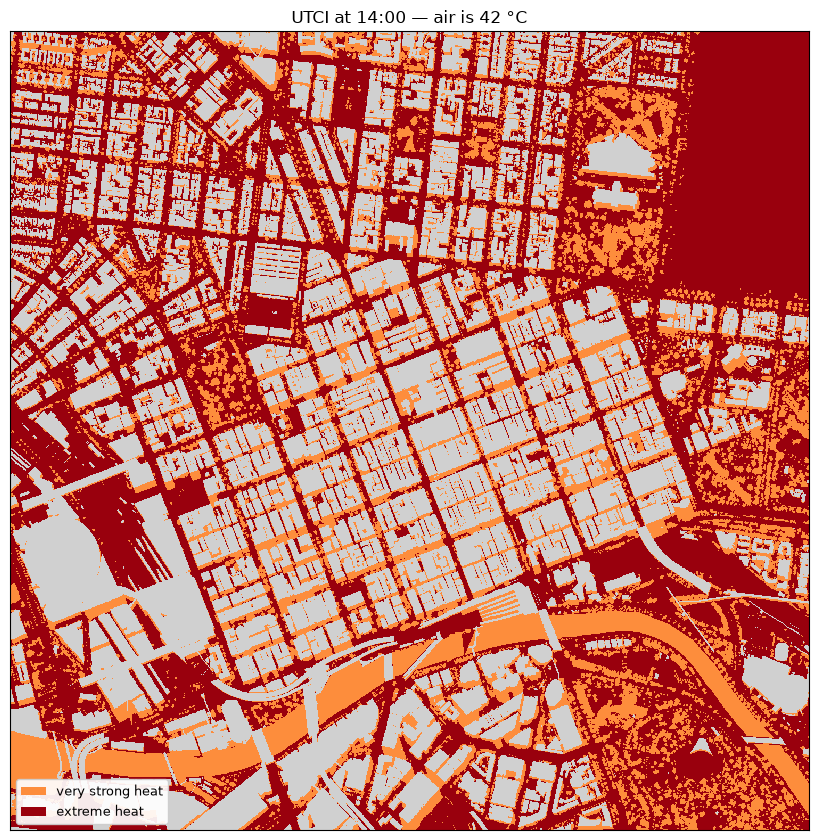

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

cmap = ListedColormap(COLOURS)
norm = BoundaryNorm([-60] + BANDS + [60], cmap.N)

fig, ax = plt.subplots(figsize=(9.5, 8.5))
ax.imshow(~ground, cmap=ListedColormap(["#ffffff", "#d0d0d0"]), interpolation="nearest")
ax.imshow(np.ma.masked_where(~ground, utci_crop[HOUR]), cmap=cmap, norm=norm,
          interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"UTCI at {HOUR}:00 — air is {w.loc[HOUR, 'temperature_2m']:.0f} °C")

seen = np.unique(band(utci_crop[HOUR][ground]))
ax.legend(handles=[Patch(facecolor=COLOURS[i], label=LABELS[i]) for i in seen],
          loc="lower left", frameon=True, facecolor="white", framealpha=0.92, fontsize=9)
fig.tight_layout()

### 10:00 and 17:00

The same city seven hours apart, on one scale. Mid-morning, shade puts you in *moderate heat
stress* while the open street is in *strong* — a real refuge. By late afternoon the whole city has
moved up: shade is *very strong* and the sun is *extreme*.

The gap between shade and sun stays about one category all day. What changes is where that gap
sits. In the morning shade gets you somewhere tolerable; in the evening the best available cell in
the CBD is still bad for you, and shade only makes it less bad, faster.

This is why the app quotes °C·minutes rather than a percentage. "68% shaded" is the same sentence
for both of these maps and hides everything that matters.

Text(0.5, 0.98, 'morning and late afternoon, same bands')

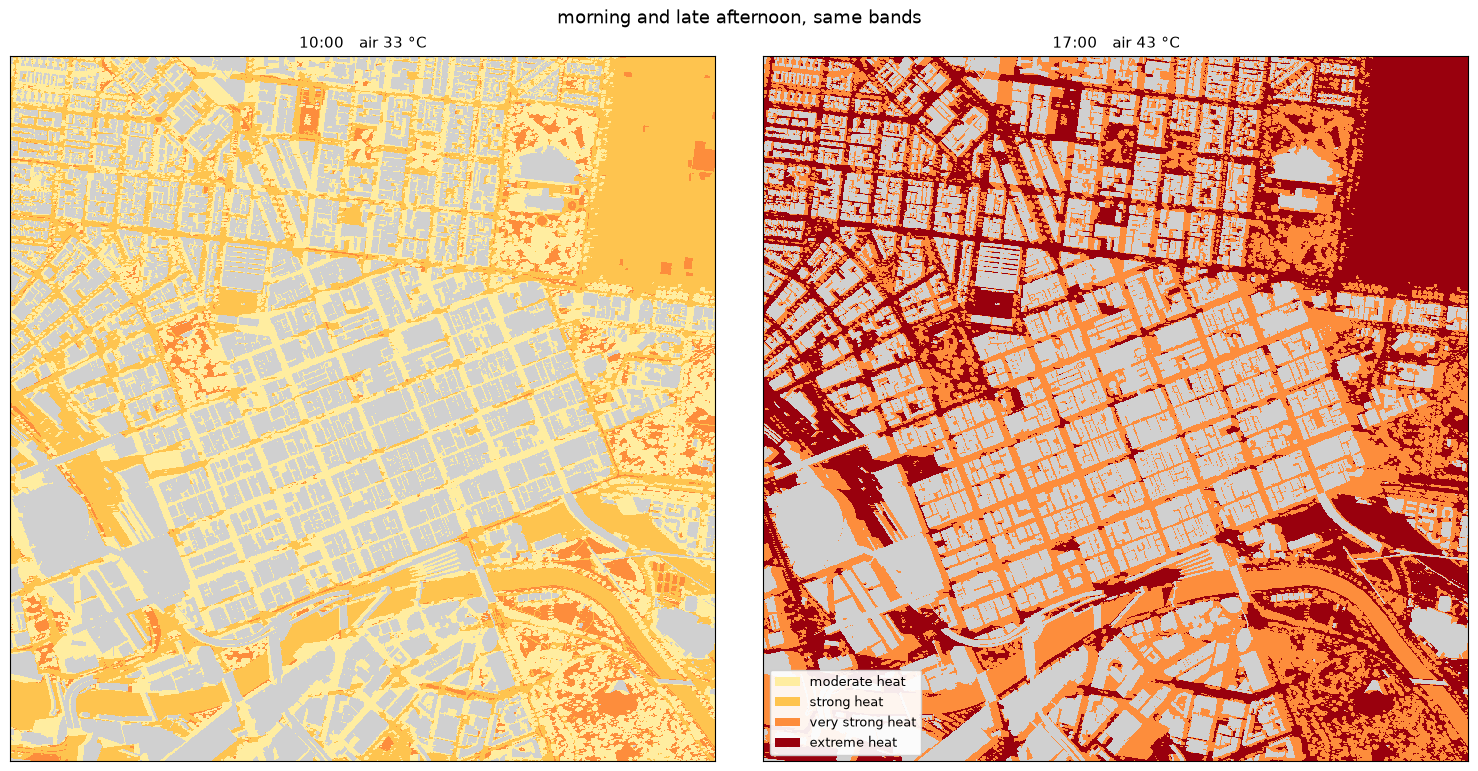

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7.6), constrained_layout=True)
for ax, h in zip(axes, (10, 17)):
    ax.imshow(~ground, cmap=ListedColormap(["#ffffff", "#d0d0d0"]), interpolation="nearest")
    ax.imshow(np.ma.masked_where(~ground, utci_crop[h]), cmap=cmap, norm=norm,
              interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{h}:00   air {w.loc[h, 'temperature_2m']:.0f} °C", fontsize=11)

seen = np.unique(np.concatenate([band(utci_crop[h][ground]) for h in (10, 17)]))
axes[1].legend(handles=[Patch(facecolor=COLOURS[i], label=LABELS[i]) for i in seen],
               loc="lower left", frameon=True, facecolor="white", framealpha=0.92, fontsize=9)
fig.suptitle("morning and late afternoon, same bands", fontsize=13)

## Why the app counts °C·minutes

A route is not a place, it is time spent in a sequence of places. So the cost of a walk is stress
multiplied by how long you are in it, summed along the way — degrees × minutes.

Two ways to cross the same block at 14:00, walking at 1.3 m/s:

In [12]:
WALK = 1.3          # m/s, an ordinary pace

routes = {"straight, in the sun": (520, "open road"),
          "the long way, in shade": (680, "shaded road")}

print(f"{'':24s} {'metres':>7s} {'minutes':>8s} {'stress':>7s} {'°C·min':>8s}")
for label, (metres, spot) in routes.items():
    r, c = SPOTS[spot]
    minutes = metres / WALK / 60
    s = stress(float(utci(ta, mrt[HOUR][r, c], va, rh)))
    print(f"{label:24s} {metres:7.0f} {minutes:8.1f} {s:7.1f} {s * minutes:8.0f}")

                          metres  minutes  stress   °C·min
straight, in the sun         520      6.7    22.7      151
the long way, in shade       680      8.7    17.4      151


The detour is 160 m longer and two minutes slower, and it still costs less. That trade is the
whole product: the shortest path and the coolest path are different paths, and °C·minutes is the
one number that can say by how much.

Phase 2 turns that into a graph and searches it.

## The whole grid

In [13]:
for h in HOURS:
    m_full = np.load(f"out/rasters/mrt_{h:02d}.npy")
    np.save(f"out/rasters/utci_{h:02d}.npy",
            utci(w.loc[h, "temperature_2m"], m_full,
                 w.loc[h, "wind_ms"], w.loc[h, "relative_humidity_2m"]).astype(np.float32))

print(f"out/rasters/utci_06.npy .. utci_20.npy   {len(HOURS)} files")

out/rasters/utci_06.npy .. utci_20.npy   15 files


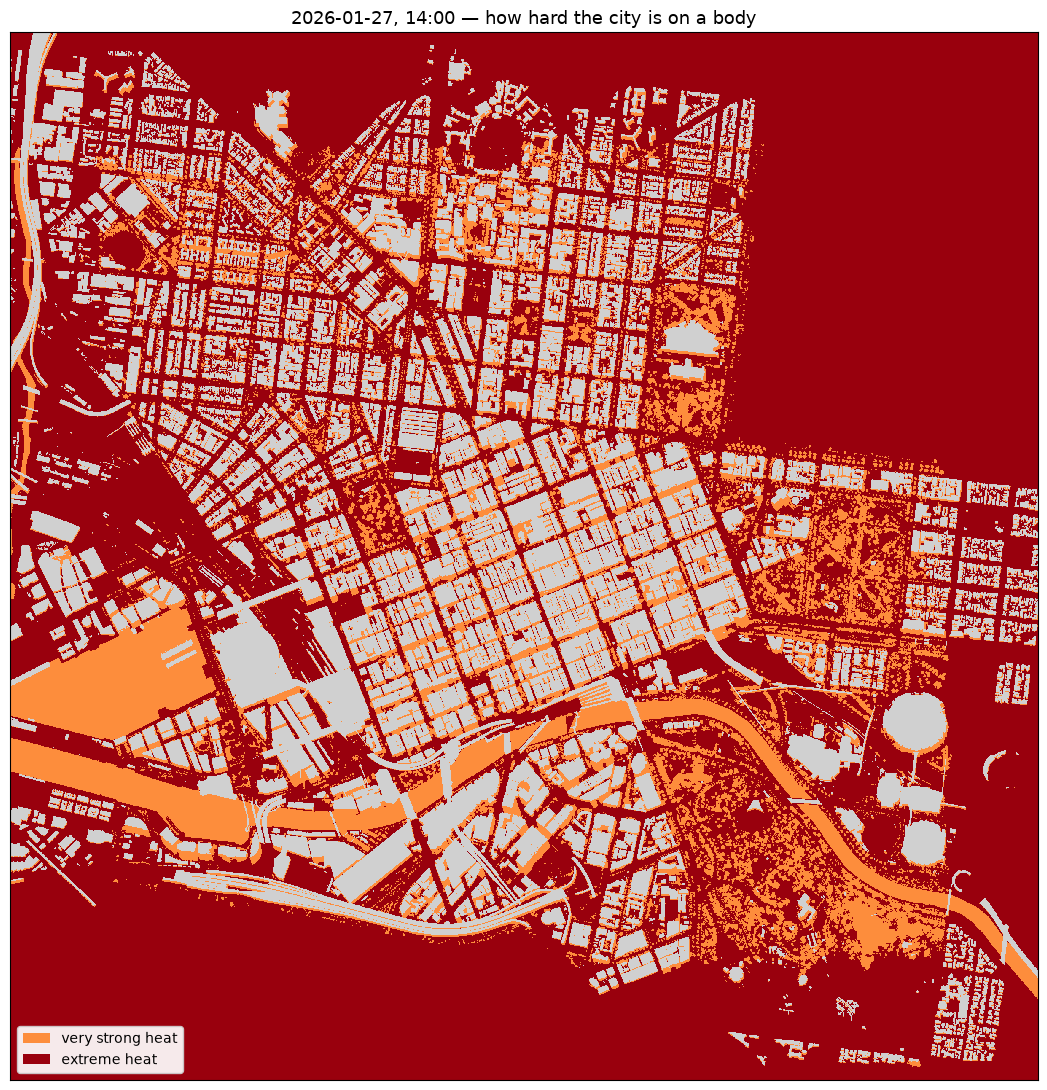

In [14]:
dsm_full = np.load("out/rasters/dsm_buildings.npy")
ground_full = dsm_full <= 0
u_full = np.load(f"out/rasters/utci_{HOUR:02d}.npy")

fig, ax = plt.subplots(figsize=(11, 11))
ax.imshow(~ground_full, cmap=ListedColormap(["#ffffff", "#d0d0d0"]), interpolation="nearest")
ax.imshow(np.ma.masked_where(~ground_full, u_full), cmap=cmap, norm=norm, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"{DATE}, {HOUR}:00 — how hard the city is on a body", fontsize=13)

seen = np.unique(band(u_full[ground_full]))
ax.legend(handles=[Patch(facecolor=COLOURS[i], label=LABELS[i]) for i in seen],
          loc="lower left", frameon=True, facecolor="white", framealpha=0.92, fontsize=10)
fig.tight_layout()